# Notebook 02 — VAD Baseline Autoencoder Training

**Goal:** Train a convolutional autoencoder on *normal* UCSD Ped2 frames only.  
At test time, anomalous frames produce higher reconstruction error — that error is our anomaly score.

**Why autoencoder first (not future-frame prediction)?**  
The autoencoder is the baseline. It's simpler, faster to train, and gives us a AUC number to beat in notebook 03 when we add the adversarial layer. Always establish your baseline before optimising.

**Checklist this notebook covers:**
- [x] Implement baseline autoencoder
- [x] Train on UCSD Ped2 train set (normal frames only), save checkpoint
- [x] Compute reconstruction error on test set
- [x] Compute frame-level AUC

## 1. Imports & Config

In [16]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

plt.style.use('seaborn-v0_8-darkgrid')

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE    = 128          # resize all frames to 128x128 (good balance speed/quality)
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-3
CHECKPOINT  = '/kaggle/working/autoencoder_ped2.pth'

# Kaggle dataset paths — adjust if your dataset slug differs
# ── Config ────────────────────────────────────────────────────────────────────
# مسیرهای استخراج شده برای محیط Kaggle شما:
TRAIN_PATH  = '/kaggle/input/datasets/orvile/ucsd-anomaly-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Train'
TEST_PATH   = '/kaggle/input/datasets/orvile/ucsd-anomaly-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test'
GT_PATH     = '/kaggle/input/datasets/orvile/ucsd-anomaly-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test'

print(f'Device: {DEVICE}')
print(f'CUDA available: {torch.cuda.is_available()}')

Device: cuda
CUDA available: True


## 2. Dataset

We load **train frames only** for training — no anomalies.  
For test we load frames + ground truth labels (0 = normal, 1 = anomaly) to compute AUC.

In [15]:
import os

# Walk everything under /kaggle/input/ and print all folders
for root, dirs, files in os.walk('/kaggle/input/'):
    level = root.replace('/kaggle/input/', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level > 4:  # stop going too deep
        break

/
datasets/
  orvile/
    ucsd-anomaly-dataset/
      UCSD_Anomaly_Dataset.v1p2/
        UCSDped1/
          Test/


In [17]:
class UCSDDataset(Dataset):
    """
    Loads .tif frames from UCSD Ped2 folder structure:
      Train/Train001/001.tif
      Test/Test001/001.tif
    """
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.frames = []

        if not os.path.exists(root_dir):
            raise FileNotFoundError(f'Path not found: {root_dir}')

        for folder in sorted(os.listdir(root_dir)):
            folder_path = os.path.join(root_dir, folder)
            # Skip ground truth folders (named *_gt)
            if os.path.isdir(folder_path) and not folder.endswith('_gt'):
                for file in sorted(os.listdir(folder_path)):
                    if file.endswith(('.tif', '.png', '.jpg')):
                        self.frames.append(os.path.join(folder_path, file))

        print(f'Loaded {len(self.frames)} frames from {root_dir}')

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx):
        img = cv2.imread(self.frames[idx], cv2.IMREAD_GRAYSCALE)  # grayscale — UCSD is greyscale
        if img is None:
            raise IOError(f'Cannot read: {self.frames[idx]}')
        if self.transform:
            img = self.transform(img)
        return img, self.frames[idx]


# Transforms: resize → tensor → normalise to [-1, 1]
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                          # [0, 1]
    transforms.Normalize(mean=[0.5], std=[0.5])     # [-1, 1]
])

train_dataset = UCSDDataset(TRAIN_PATH, transform=train_transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

test_dataset  = UCSDDataset(TEST_PATH,  transform=train_transform)
test_loader   = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

Loaded 2550 frames from /kaggle/input/datasets/orvile/ucsd-anomaly-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Train
Loaded 2010 frames from /kaggle/input/datasets/orvile/ucsd-anomaly-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test


## 3. Load Ground Truth Labels

UCSD Ped2 ships with per-frame binary labels in `*_gt` folders (`.bmp` mask files).  
A frame is anomalous (label=1) if its mask has any non-zero pixel.

In [18]:
def load_ground_truth(gt_root):
    """
    Returns a flat list of binary labels (0=normal, 1=anomaly)
    matching the order frames are loaded in UCSDDataset.
    """
    labels = []
    for folder in sorted(os.listdir(gt_root)):
        if folder.endswith('_gt'):
            folder_path = os.path.join(gt_root, folder)
            for file in sorted(os.listdir(folder_path)):
                if file.endswith(('.bmp', '.png')):
                    mask = cv2.imread(os.path.join(folder_path, file), cv2.IMREAD_GRAYSCALE)
                    # Any non-zero pixel = anomaly present in this frame
                    labels.append(1 if mask.max() > 0 else 0)
    return labels


gt_labels = load_ground_truth(GT_PATH)
print(f'GT labels loaded: {len(gt_labels)} frames')
print(f'Anomaly frames: {sum(gt_labels)} / {len(gt_labels)} ({100*sum(gt_labels)/len(gt_labels):.1f}%)')

GT labels loaded: 2010 frames
Anomaly frames: 1648 / 2010 (82.0%)


## 4. Model — Convolutional Autoencoder

**Architecture:**
- Encoder: 4 conv blocks (Conv → BatchNorm → ReLU → MaxPool) — compresses 128×128 → 8×8 latent
- Decoder: 4 upsample blocks (Upsample → Conv → BatchNorm → ReLU) — reconstructs back to 128×128

**Interview question: why does this detect anomalies?**  
Trained only on normal data, the model learns to reconstruct normal patterns efficiently.  
Anomalous patterns were never seen in training, so reconstruction fails → high MSE → high anomaly score.

In [19]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # ── Encoder ───────────────────────────────────────────────────────────
        # Input: (B, 1, 128, 128)
        self.encoder = nn.Sequential(
            # Block 1: 128 → 64
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # 64×64

            # Block 2: 64 → 32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # 32×32

            # Block 3: 32 → 16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # 16×16

            # Block 4: 16 → 8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # 8×8  ← latent space
        )

        # ── Decoder ───────────────────────────────────────────────────────────
        # Output: (B, 1, 128, 128)
        self.decoder = nn.Sequential(
            # Block 1: 8 → 16
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # Block 2: 16 → 32
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # Block 3: 32 → 64
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # Block 4: 64 → 128
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Tanh()                                 # output in [-1, 1] matching our normalisation
        )

    def forward(self, x):
        latent = self.encoder(x)
        recon  = self.decoder(latent)
        return recon


model = ConvAutoencoder().to(DEVICE)

# Quick sanity check — pass a dummy batch through
dummy = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
out   = model(dummy)
print(f'Input shape:  {dummy.shape}')
print(f'Output shape: {out.shape}')   # should match input

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Input shape:  torch.Size([1, 1, 128, 128])
Output shape: torch.Size([1, 1, 128, 128])
Total parameters: 776,833


## 5. Training Loop

Loss = MSE between input frame and reconstructed frame.  
We save the best checkpoint (lowest val loss) so a disconnected Kaggle session doesn't lose progress.

In [21]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
# Reduce LR if loss plateaus — useful on free-tier GPU
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

train_losses = []
best_loss    = float('inf')

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch_idx, (frames, _) in enumerate(train_loader):
        frames = frames.to(DEVICE)

        optimizer.zero_grad()
        recon = model(frames)
        loss  = criterion(recon, frames)   # reconstruct input = target
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    # Save checkpoint whenever we improve
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'loss':        best_loss,
        }, CHECKPOINT)
        print(f'Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.6f}  ← checkpoint saved')
    else:
        print(f'Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.6f}')

print(f'\nTraining complete. Best loss: {best_loss:.6f}')
print(f'Checkpoint saved to: {CHECKPOINT}')

Epoch   1/30 | Loss: 0.030746  ← checkpoint saved
Epoch   2/30 | Loss: 0.011516  ← checkpoint saved
Epoch   3/30 | Loss: 0.008843  ← checkpoint saved
Epoch   4/30 | Loss: 0.007568  ← checkpoint saved
Epoch   5/30 | Loss: 0.006682  ← checkpoint saved
Epoch   6/30 | Loss: 0.006073  ← checkpoint saved
Epoch   7/30 | Loss: 0.005579  ← checkpoint saved
Epoch   8/30 | Loss: 0.005328  ← checkpoint saved
Epoch   9/30 | Loss: 0.005030  ← checkpoint saved
Epoch  10/30 | Loss: 0.004821  ← checkpoint saved
Epoch  11/30 | Loss: 0.004616  ← checkpoint saved
Epoch  12/30 | Loss: 0.004440  ← checkpoint saved
Epoch  13/30 | Loss: 0.004325  ← checkpoint saved
Epoch  14/30 | Loss: 0.004150  ← checkpoint saved
Epoch  15/30 | Loss: 0.004054  ← checkpoint saved
Epoch  16/30 | Loss: 0.003949  ← checkpoint saved
Epoch  17/30 | Loss: 0.003810  ← checkpoint saved
Epoch  18/30 | Loss: 0.003770  ← checkpoint saved
Epoch  19/30 | Loss: 0.003675  ← checkpoint saved
Epoch  20/30 | Loss: 0.003609  ← checkpoint saved


## 6. Training Loss Curve

A smooth decreasing curve = the model is learning to reconstruct normal frames.  
Plateau early = try lowering LR or increasing epochs.

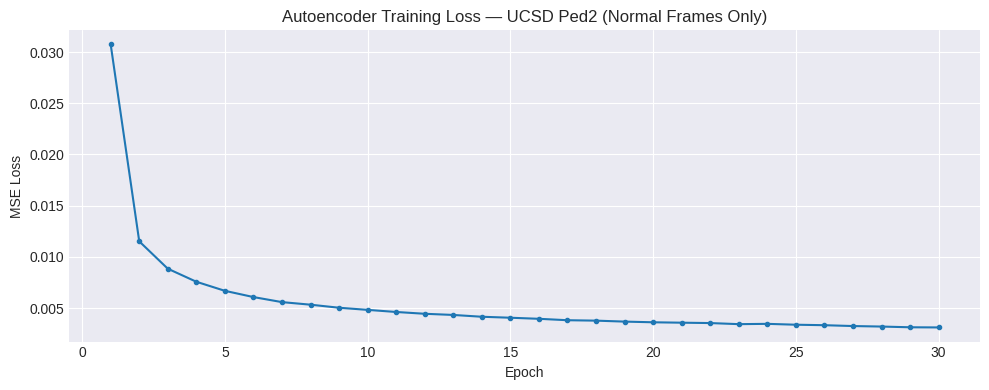

Loss curve saved → /kaggle/working/training_loss.png


In [22]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', markersize=3, linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Loss — UCSD Ped2 (Normal Frames Only)')
plt.tight_layout()
plt.savefig('/kaggle/working/training_loss.png', dpi=150)
plt.show()
print('Loss curve saved → /kaggle/working/training_loss.png')

## 7. Evaluation — Reconstruction Error on Test Set

For each test frame we compute MSE(input, reconstruction).  
This is our **anomaly score** — higher score = more likely anomalous.  
We then compare scores against ground truth labels to compute frame-level AUC.

In [23]:
# Load best checkpoint
checkpoint = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Loaded checkpoint from epoch {checkpoint['epoch']} (loss={checkpoint['loss']:.6f})")

# Compute per-frame reconstruction error
recon_errors = []

with torch.no_grad():
    for frames, _ in test_loader:
        frames = frames.to(DEVICE)
        recon  = model(frames)
        # MSE per frame (mean over all pixels)
        error  = torch.mean((frames - recon) ** 2).item()
        recon_errors.append(error)

print(f'Test frames evaluated: {len(recon_errors)}')
print(f'Mean reconstruction error: {np.mean(recon_errors):.6f}')
print(f'Max reconstruction error:  {np.max(recon_errors):.6f}')

Loaded checkpoint from epoch 30 (loss=0.003106)
Test frames evaluated: 2010
Mean reconstruction error: 0.006691
Max reconstruction error:  0.010694


## 8. Frame-Level AUC

AUC measures how well reconstruction error separates normal from anomalous frames.  
- AUC = 0.5 → random (model learned nothing useful)
- AUC = 1.0 → perfect separation
- Target for this baseline: AUC ≥ 0.70

In [25]:
# Align lengths — GT labels and test frames must match
min_len = min(len(recon_errors), len(gt_labels))
scores  = recon_errors[:min_len]
labels  = gt_labels[:min_len]

if len(set(labels)) < 2:
    print('Warning: only one class in GT labels — check GT loading.')
else:
    auc = roc_auc_score(labels, scores)
    print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  Frame-level AUC: {auc:.4f}')
    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  Baseline target: ≥ 0.70')
    print(f'  Status: {"✓ PASS" if auc >= 0.70 else "✗ below target — see notes below"}')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Frame-level AUC: 0.6240
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Baseline target: ≥ 0.70
  Status: ✗ below target — see notes below


## 9. Visualise — Reconstruction Error Over Time

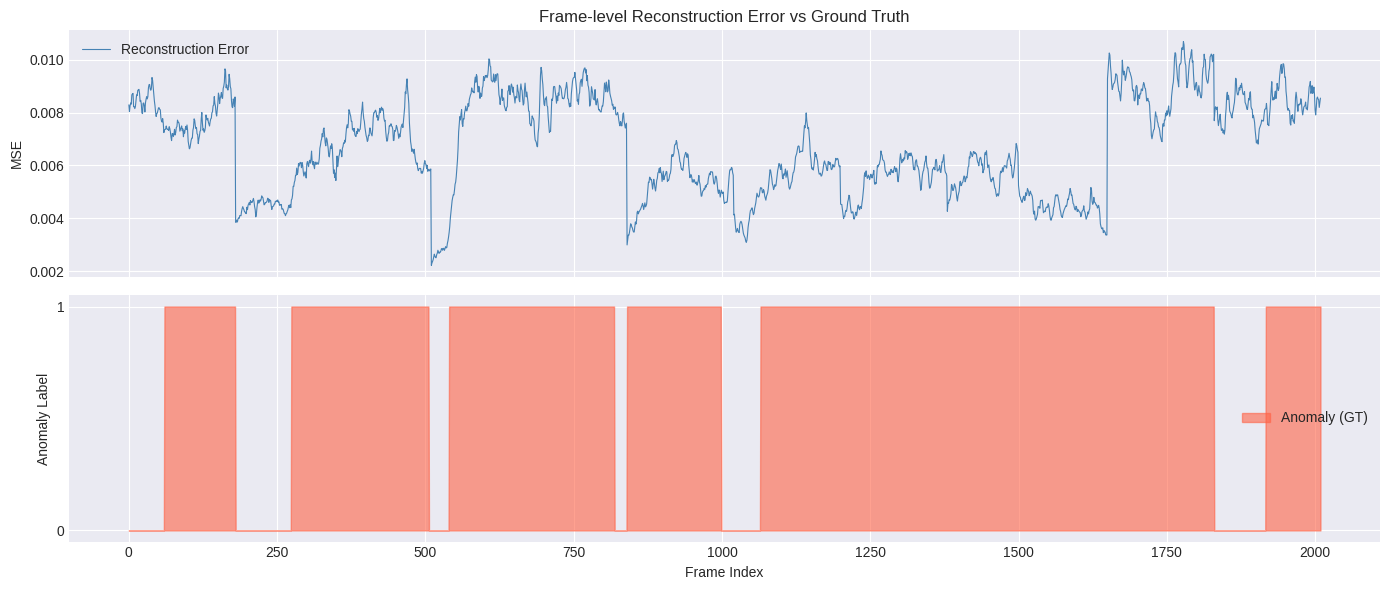

Error plot saved → /kaggle/working/error_vs_gt.png


In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Top: reconstruction error
axes[0].plot(scores, color='steelblue', linewidth=0.8, label='Reconstruction Error')
axes[0].set_ylabel('MSE')
axes[0].set_title('Frame-level Reconstruction Error vs Ground Truth')
axes[0].legend()

# Bottom: ground truth labels
axes[1].fill_between(range(len(labels)), labels, alpha=0.6, color='tomato', label='Anomaly (GT)')
axes[1].set_ylabel('Anomaly Label')
axes[1].set_xlabel('Frame Index')
axes[1].set_yticks([0, 1])
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/error_vs_gt.png', dpi=150)
plt.show()
print('Error plot saved → /kaggle/working/error_vs_gt.png')

## 10. Visualise — Input vs Reconstruction (Normal & Anomalous)

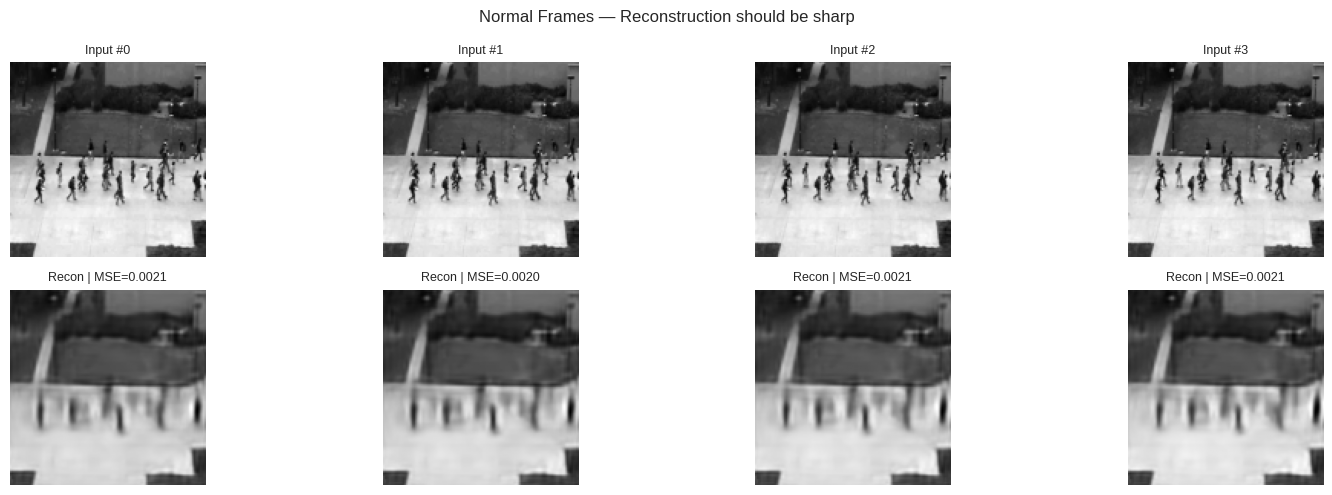

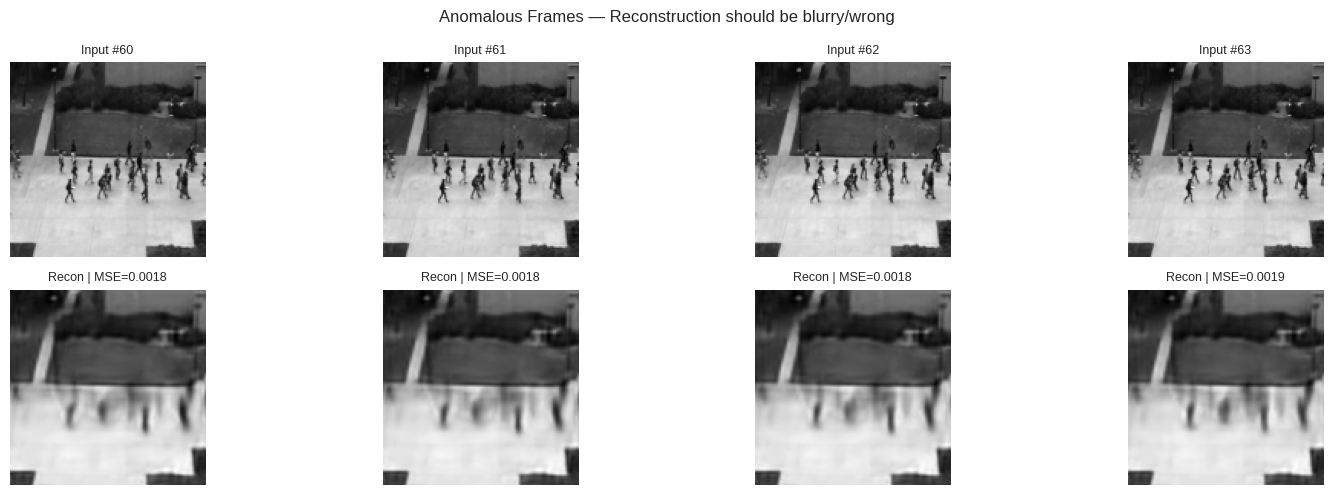

In [27]:
def show_reconstruction(model, dataset, indices, title):
    """Plot input vs reconstruction for given frame indices."""
    fig, axes = plt.subplots(2, len(indices), figsize=(4 * len(indices), 5))
    model.eval()

    for col, idx in enumerate(indices):
        frame, _ = dataset[idx]
        frame_in = frame.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            recon = model(frame_in)

        # Convert back to [0,1] for display
        orig_np  = (frame.squeeze().numpy() * 0.5) + 0.5
        recon_np = (recon.squeeze().cpu().numpy() * 0.5) + 0.5

        axes[0, col].imshow(orig_np, cmap='gray')
        axes[0, col].set_title(f'Input #{idx}', fontsize=9)
        axes[0, col].axis('off')

        axes[1, col].imshow(recon_np, cmap='gray')
        mse = np.mean((orig_np - recon_np) ** 2)
        axes[1, col].set_title(f'Recon | MSE={mse:.4f}', fontsize=9)
        axes[1, col].axis('off')

    axes[0, 0].set_ylabel('Input', fontsize=10)
    axes[1, 0].set_ylabel('Reconstruction', fontsize=10)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

# Sample a few normal frames (label=0) and anomalous frames (label=1)
normal_idx = [i for i, l in enumerate(labels) if l == 0][:4]
anom_idx   = [i for i, l in enumerate(labels) if l == 1][:4]

show_reconstruction(model, test_dataset, normal_idx, 'Normal Frames — Reconstruction should be sharp')
show_reconstruction(model, test_dataset, anom_idx,   'Anomalous Frames — Reconstruction should be blurry/wrong')

## 11. Notes — If AUC Is Below 0.70

| Symptom | Likely Cause | Fix |
|---|---|---|
| AUC ≈ 0.5 | Model not converging | Train longer, lower LR |
| Loss still falling at epoch 30 | Underfitting | Increase EPOCHS to 50 |
| Normal and anomaly errors look similar | Latent space too large | Reduce encoder depth |
| GT label count ≠ test frame count | GT loading mismatch | Print both lengths and debug `load_ground_truth` |

**Next notebook:** `03_attack_eval.ipynb` — FGSM and PGD attacks on this trained model.

---
*Screenshot this cell's output (especially the AUC score) and save to `doc/screenshots/02_auc_result.png`.*